In [1]:
from TrainAndTest.test import evaluate_classification_model
from Preprocessing.VideoPreprocessor import VideoHandler
from DatasetReaders.VideoDataset import VideoDataset
from TrainAndTest.train import train, EarlyStopping
from DetectionModels.VideoResNet import VideoResNet
from torch.utils.data import DataLoader
import torchvision.transforms as T
from torch import nn
import pandas as pd
import torch

device= "cuda"

## 1. Dataset Loading 

In [2]:
def clean_prefix(path):
    if path.startswith(".."):
        return path.replace("..\\", "")
    return path
    
df= pd.read_csv(r"DataAnalysis\new_meta_data.csv")
df["path"]= df["path"].apply(clean_prefix)
df= df[df["duration"]>3.0]

real_df= df[(df['method'] == 'real') & (df['video_class'] == 0)]
fake_df= df[df['video_class'] == 1]

real_df= real_df.sample(frac=1, random_state=42).reset_index(drop=True)
train_real= real_df.iloc[:300]         
val_real= real_df.iloc[300:400]      
test_real= real_df.iloc[400:500]      
samples= [train_real]
fakes_config= [
    {'method': 'wav2lip',          'count': 100},
    {'method': 'fsgan',            'count': 100},
    {'method': 'fsgan-wav2lip',    'count': 100},
    {'method': 'faceswap-wav2lip', 'count': 100},
    {'method': 'faceswap',         'count': 100}
]

for config in fakes_config:
    subset= fake_df[fake_df['method'] == config['method']]
    samples.append(subset.sample(n=config['count'], random_state=42))

train_dataset_df= pd.concat(samples).sample(frac=1, random_state=42).reset_index(drop=True)
val_samples= [val_real]
for config in fakes_config:
    subset= fake_df[fake_df['method'] == config['method']]
    subset= subset.drop(subset[subset.index.isin(train_dataset_df.index)].index)
    val_samples.append(subset.sample(n=20, random_state=42)) 

val_dataset_df= pd.concat(val_samples).sample(frac=1, random_state=42).reset_index(drop=True)
test_samples= [test_real] 
for config in fakes_config:
    subset= fake_df[fake_df['method'] == config['method']]
    used_indices= train_dataset_df.index.union(val_dataset_df.index)
    subset= subset[~subset['path'].isin(train_dataset_df['path'])]
    subset= subset[~subset['path'].isin(val_dataset_df['path'])]
    test_samples.append(subset.sample(n=20, random_state=42))

test_dataset_df= pd.concat(test_samples).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Train Size: {len(train_dataset_df)} (Real: {len(train_real)})")
print(f"Val Size:   {len(val_dataset_df)}   (Real: {len(val_real)})")
print(f"Test Size:  {len(test_dataset_df)}  (Real: {len(test_real)})")

Train Size: 800 (Real: 300)
Val Size:   200   (Real: 100)
Test Size:  200  (Real: 100)


In [3]:
train_video_transform= T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    T.RandomErasing(p=0.5, scale=(0.02, 0.2)),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    
])

train_video_processor= VideoHandler(train_video_transform,3.0,25,device)

train_dataset= VideoDataset(train_dataset_df,train_video_processor)
train_data_loader= DataLoader(
    train_dataset,
    batch_size=4
)

In [4]:
val_video_transform= T.Compose([
    T.Resize((224, 224)),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    
])
val_video_processor= VideoHandler(val_video_transform,3.0,25,device)
val_dataset= VideoDataset(val_dataset_df,val_video_processor)
val_data_loader= DataLoader(
    val_dataset,
    batch_size=4
)

## 2. Model Training and testing

In [6]:
model= VideoResNet(num_classes=2).to(device)
early_stopper= EarlyStopping(patience=5)
loss_fn= nn.CrossEntropyLoss(label_smoothing=0.1)
optimiser= torch.optim.Adam(model.parameters(), lr=0.0001, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimiser, 
    mode='min', 
    factor=0.1, 
    patience=3
)
train_loss, val_loss= train(model,
                            train_data_loader,
                            loss_fn, optimiser,
                            device,
                            100,
                            early_stopper,
                            val_data_loader,
                            "Video_model.pth",
                            False,
                            scheduler=scheduler)

epoch 1
loss: 1.2006110291928054
Validation Loss: 0.6497890996932983
Current Learning Rate: 0.000100
epoch 2
loss: 0.7260562378168106
Validation Loss: 0.5997776764631272
Current Learning Rate: 0.000100
epoch 3
loss: 0.6279639542847871
Validation Loss: 0.5700480502843857
Current Learning Rate: 0.000100
epoch 4
loss: 0.5806888058036566
Validation Loss: 0.556595288515091
Current Learning Rate: 0.000100
epoch 5
loss: 0.5529980688542128
Validation Loss: 0.5419689655303955
Current Learning Rate: 0.000100
epoch 6
loss: 0.5532535535097122
Validation Loss: 0.5309476310014725
Current Learning Rate: 0.000100
epoch 7
loss: 0.5544771020114422
Validation Loss: 0.5268457216024399
Current Learning Rate: 0.000100
epoch 8
loss: 0.5073432106524706
Validation Loss: 0.5164292395114899
Current Learning Rate: 0.000100
epoch 9
loss: 0.5300187250226736
Validation Loss: 0.5217979443073273
EarlyStopping counter: 1/5
Current Learning Rate: 0.000100
epoch 10
loss: 0.5223452563583851
Validation Loss: 0.525895459651

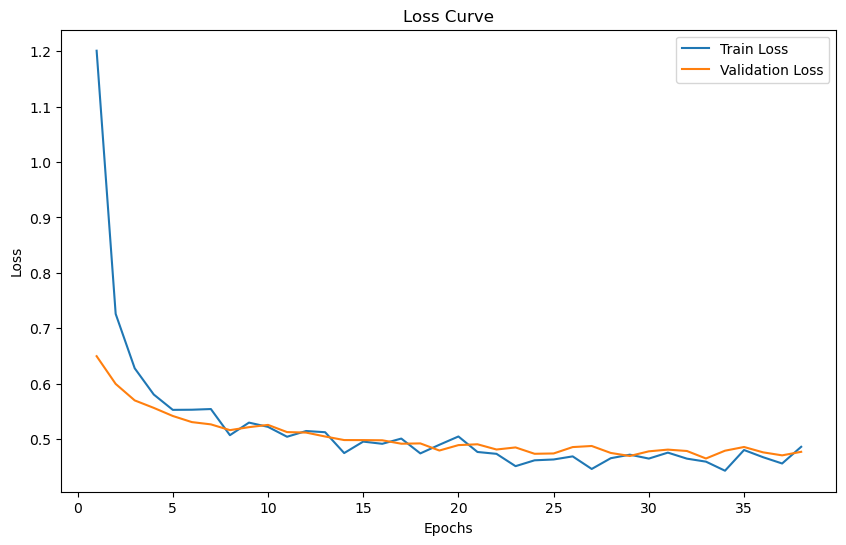

In [7]:
import matplotlib.pyplot as plt
plt.figure(figsize= (10,6))
plt.plot(range(1, len(train_loss)+1), train_loss, label= "Train Loss")
plt.plot(range(1, len(val_loss)+1), val_loss, label= "Validation Loss")
plt.title("Loss Curve")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()
plt.show();

In [8]:
torch.manual_seed(0)

modelt= VideoResNet(num_classes=2).to(device)
state_dict= torch.load("Video_model.pth", weights_only=True)
modelt.load_state_dict(state_dict=state_dict)
modelt.eval()
test_dataset= VideoDataset(
    test_dataset_df,
    val_video_processor
)
test_loader= DataLoader(
    test_dataset,
    batch_size= 2
)
acc, prec, rec, f1= evaluate_classification_model(modelt, test_loader, device)

Accuracy: 0.8900
Precision: 0.8957
Recall: 0.8900
F1-score: 0.8896
